
# 📊 EDA de un portafolio de activos con Python
### Matplotlib · Seaborn · Pandas · yfinance

**Curso:** Lenguajes de programación  
**Tema:** Visualización y Análisis Exploratorio de Datos (EDA)  
**Caso:** análisis exploratorio de un portafolio de activos financieros

---

## 🎯 ¿Qué vamos a aprender?

Al terminar este notebook podrás:

- reconocer qué es una librería y para qué sirve;
- diferenciar **dato, variable, gráfico e interpretación**;
- crear gráficos básicos con **Matplotlib**;
- utilizar **Seaborn** para explorar distribuciones y relaciones;
- interpretar correctamente los gráficos;
- descargar datos históricos con **yfinance**;
- calcular rendimientos;
- explorar volatilidad, distribución y correlación;
- construir una primera lectura exploratoria de un portafolio.

> **Idea central:** un gráfico no es el resultado del análisis.  
> El gráfico es una herramienta que nos ayuda a **formular preguntas, encontrar patrones y comunicar hallazgos**.



## 🧭 Ruta de la clase

Trabajaremos de manera incremental:

**1. Datos → 2. Variables → 3. Gráfico → 4. Interpretación → 5. EDA → 6. Datos financieros reales**

| Etapa | Pregunta |
|---|---|
| Conceptos | ¿Qué estamos visualizando? |
| Matplotlib | ¿Cómo se construye un gráfico? |
| Seaborn | ¿Cómo exploramos una variable o relación? |
| EDA | ¿Qué patrones encontramos? |
| yfinance | ¿Cómo trabajamos con datos reales? |
| Portafolio | ¿Cómo se comportan conjuntamente los activos? |



# 1. Antes de graficar: pensemos como analistas

Supongamos que tenemos:

| Día | Precio |
|---:|---:|
| 1 | 100 |
| 2 | 103 |
| 3 | 101 |
| 4 | 108 |
| 5 | 112 |

Tenemos dos conceptos diferentes:

### Variable
Una característica que podemos observar o medir.  
Ejemplo: `Precio`.

### Observación
Un valor concreto de una variable.  
Ejemplo: el precio del día 4 es `108`.

### ¿Por qué graficar?

La tabla nos da los valores. El gráfico nos permite **ver la estructura de los datos**.

Por ejemplo:

- ¿el precio está aumentando?
- ¿hay caídas?
- ¿hay cambios bruscos?
- ¿existe una tendencia?

Ese proceso de preguntar, observar y encontrar patrones forma parte del **Análisis Exploratorio de Datos (EDA)**.



# 2. Las librerías que vamos a utilizar

Una **librería** es un conjunto de código reutilizable que otras personas han desarrollado para resolver problemas.

Hoy utilizaremos:

### 🐼 Pandas
Para trabajar con datos tabulares.

### 📈 Matplotlib
Para construir y personalizar visualizaciones.

### 🎨 Seaborn
Para crear visualizaciones estadísticas de forma sencilla y trabajar cómodamente con DataFrames.

### 💰 yfinance
Para obtener datos históricos de activos financieros desde Yahoo Finance.

La relación será:

```text
yfinance
   ↓
datos financieros
   ↓
Pandas
   ↓
transformaciones
   ↓
Matplotlib / Seaborn
   ↓
visualización
   ↓
interpretación
```


In [1]:
# Importamos las librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual básica
sns.set_theme(style="whitegrid")

# Para que los gráficos aparezcan dentro del notebook
%matplotlib inline



## ¿Qué significa `import`?

Cuando escribimos:

```python
import matplotlib.pyplot as plt
```

estamos diciendo:

> "Quiero utilizar el módulo `pyplot` de la librería `matplotlib` y voy a llamarlo `plt`."

Por eso posteriormente podemos escribir:

```python
plt.plot(...)
```

El nombre `plt` es un **alias**. No es obligatorio llamarlo así, pero es una convención muy utilizada.

Lo mismo ocurre con:

```python
import seaborn as sns
import pandas as pd
import numpy as np
```



# 3. Nuestro primer gráfico: de una tabla a una visualización

Comencemos con datos muy pequeños para entender **qué hace cada instrucción**.

Tenemos el precio de un activo durante cinco días.


In [2]:
dias = [1, 2, 3, 4, 5]
precios = [100, 103, 101, 108, 112]

datos_ejemplo = pd.DataFrame({
    "Día": dias,
    "Precio": precios
})

datos_ejemplo


,Día,Precio
0,1,100
1,2,103
2,3,101
3,4,108
4,5,112



### Primer intento

Queremos representar:

- eje X → día
- eje Y → precio

La función `plot()` recibe normalmente una serie de valores para X y otra para Y.


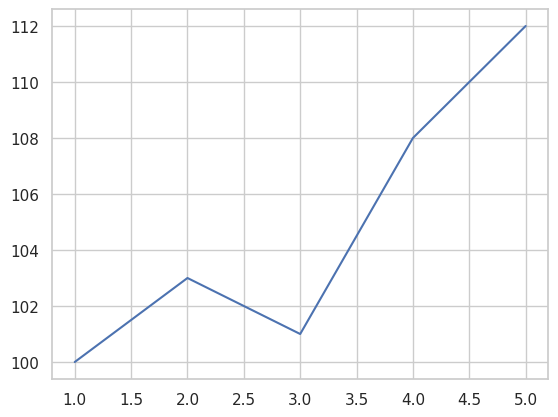

In [3]:
plt.plot(dias, precios)
plt.show()



## 🔎 ¿Qué acaba de ocurrir?

`plt.plot(x, y)`:

- toma los valores de `x`;
- toma los valores de `y`;
- coloca cada par `(x, y)` en el plano;
- conecta los puntos.

En nuestro ejemplo:

```text
(1,100)
(2,103)
(3,101)
(4,108)
(5,112)
```

### ¿Cómo lo interpretamos?

No debemos decir simplemente "el gráfico sube".

Podemos decir:

> **El precio presenta una tendencia general creciente durante el período observado, aunque existe una disminución entre los días 2 y 3.**

Esa segunda frase ya es una **interpretación**.



# 4. Hacer que el gráfico comunique mejor

Un gráfico debe permitir que otra persona entienda rápidamente:

1. **qué está viendo**;
2. **qué representan los ejes**;
3. **qué unidad se está utilizando**;
4. **qué período se está observando**.

Para eso agregamos título y etiquetas.


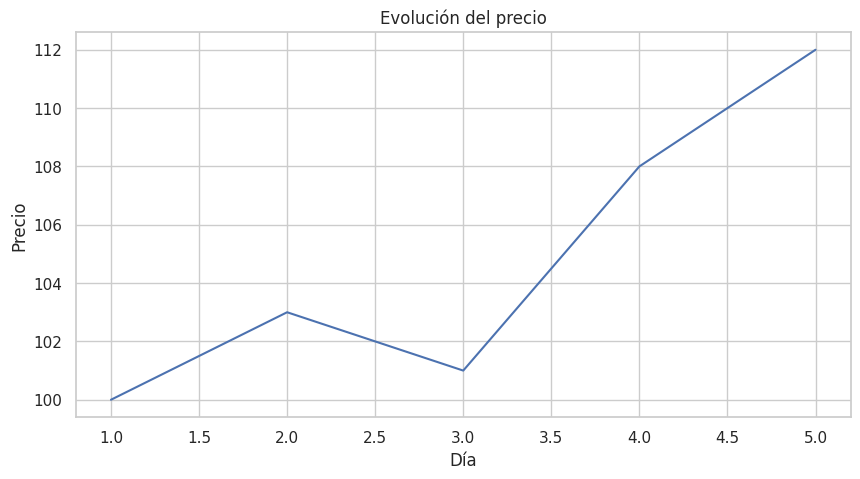

In [4]:
plt.figure(figsize=(10, 5))

plt.plot(dias, precios)

plt.title("Evolución del precio")
plt.xlabel("Día")
plt.ylabel("Precio")

plt.show()



## 🧩 Anatomía de un gráfico

```text
                 TÍTULO
        Evolución del precio

  Y
  ↑
  │             ●
  │          ●
  │     ●
  │        ●
  │  ●
  └──────────────────────→ X
       Día
```

### Elementos principales

- **Título:** comunica qué estamos observando.
- **Eje X:** normalmente representa tiempo o una variable explicativa.
- **Eje Y:** representa la variable que queremos analizar.
- **Línea/puntos:** representan los datos.
- **Leyenda:** identifica las series cuando tenemos varias.



# 5. La interfaz orientada a objetos de Matplotlib

Hasta ahora utilizamos `plt` directamente.

Existe otra forma muy importante:

```python
fig, ax = plt.subplots()
```

Aquí aparecen dos objetos:

### `fig`
Es la **figura completa**, el espacio donde estará nuestro gráfico.

### `ax`
Es el **área de ejes** donde realmente dibujamos.

Una forma sencilla de imaginarlo:

```text
Figure
┌─────────────────────────────┐
│                             │
│       Axes                  │
│     ┌───────────────┐       │
│     │   gráfico     │       │
│     │               │       │
│     └───────────────┘       │
│                             │
└─────────────────────────────┘
```


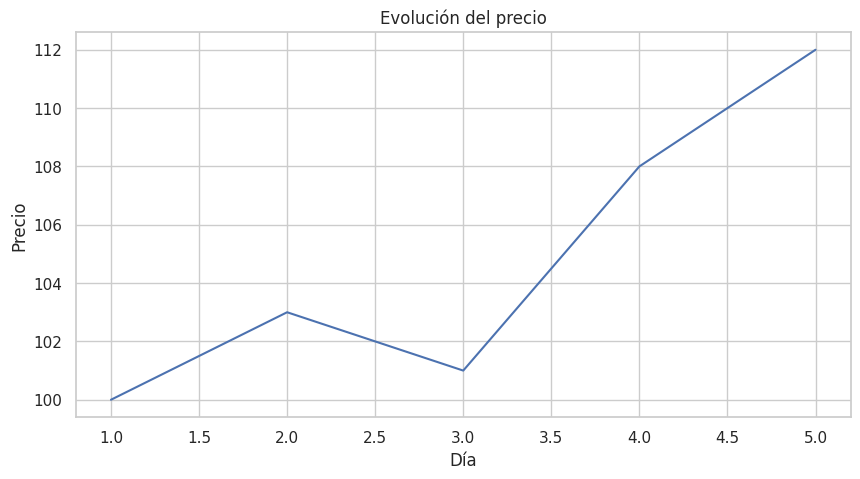

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(dias, precios)

ax.set_title("Evolución del precio")
ax.set_xlabel("Día")
ax.set_ylabel("Precio")

plt.show()



### ¿Por qué aprender esta forma?

Cuando los gráficos se vuelven más complejos, trabajar con `fig` y `ax` nos da mayor control.

Por ejemplo, podemos tener varios gráficos dentro de una misma figura y controlar cada eje por separado.

**Regla práctica para la clase:**

- `plt.plot()` → muy útil para comenzar.
- `fig, ax = plt.subplots()` → recomendable cuando queremos construir gráficos de forma más estructurada.



# 6. Gráficos de varias series

Ahora supongamos que tenemos tres activos.


In [6]:
precios_portafolio = pd.DataFrame({
    "AAPL": [100, 103, 101, 108, 112],
    "MSFT": [100, 102, 104, 106, 109],
    "NVDA": [100, 98, 105, 110, 120]
}, index=[1, 2, 3, 4, 5])

precios_portafolio


,AAPL,MSFT,NVDA
1,100,100,100
2,103,102,98
3,101,104,105
4,108,106,110
5,112,109,120



Si graficamos los precios directamente, podemos comparar las series.

Pero aparece un problema importante:

> ¿Cómo comparamos activos que originalmente tienen precios diferentes?

Por ahora nuestros datos comienzan todos en 100. Esto es intencional: queremos concentrarnos en la **forma de la serie** antes de introducir los rendimientos.


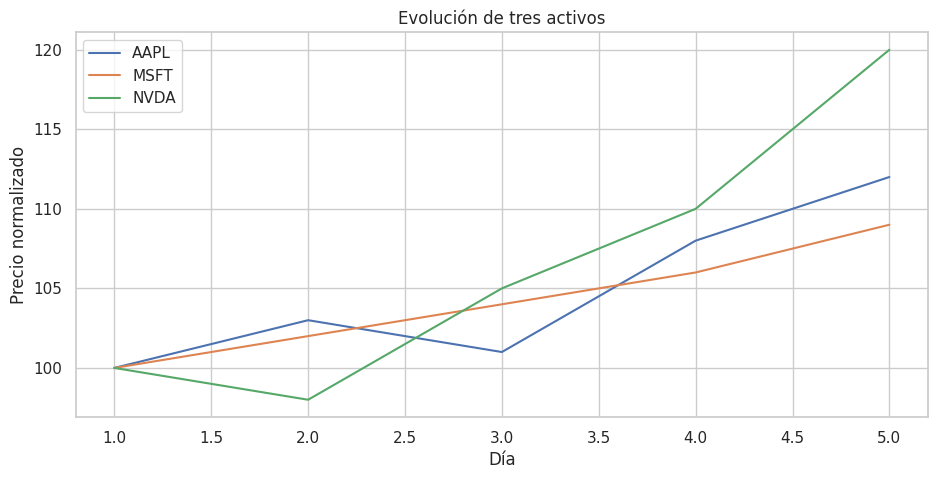

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(precios_portafolio.index, precios_portafolio["AAPL"], label="AAPL")
ax.plot(precios_portafolio.index, precios_portafolio["MSFT"], label="MSFT")
ax.plot(precios_portafolio.index, precios_portafolio["NVDA"], label="NVDA")

ax.set_title("Evolución de tres activos")
ax.set_xlabel("Día")
ax.set_ylabel("Precio normalizado")
ax.legend()

plt.show()



## 🧠 Interpretación

Observe primero, **después interprete**.

Preguntas:

1. ¿Cuál serie termina más arriba?
2. ¿Cuál presenta más cambios?
3. ¿Hay momentos en los que dos activos se mueven en direcciones diferentes?
4. ¿Podemos concluir cuál es "mejor" solamente con este gráfico?

La última pregunta es importante:

> **No.** Un gráfico puede mostrar comportamiento histórico, pero no convierte automáticamente ese comportamiento en una recomendación de inversión.



# 7. Seaborn: visualización orientada al análisis estadístico

Seaborn está construido sobre Matplotlib y facilita muchos gráficos estadísticos.

Una ventaja importante es que puede trabajar directamente con estructuras de Pandas.

Vamos a utilizar primero un **histograma**.


In [8]:
# Generamos una muestra sencilla de rendimientos

np.random.seed(42)

rendimientos_ejemplo = np.random.normal(
    loc=0.001,
    scale=0.02,
    size=500
)

rendimientos_ejemplo[:10]


array([ 0.01093428, -0.00176529,  0.01395377,  0.0314606 , -0.00368307,
       -0.00368274,  0.03258426,  0.01634869, -0.00838949,  0.0118512 ])


## ¿Qué pregunta responde un histograma?

Un histograma permite observar cómo se distribuyen los valores.

Por ejemplo:

> ¿En qué rango se concentran los rendimientos?


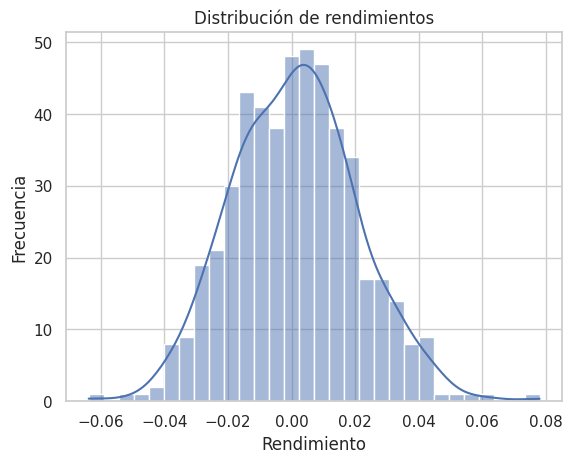

In [9]:
sns.histplot(
    rendimientos_ejemplo,
    bins=30,
    kde=True
)

plt.title("Distribución de rendimientos")
plt.xlabel("Rendimiento")
plt.ylabel("Frecuencia")

plt.show()



## 🔎 ¿Cómo interpretar un histograma?

Observemos:

### Centro
¿Dónde se concentran la mayoría de los valores?

### Dispersión
¿Qué tan extendidos están los datos?

### Colas
¿Hay valores alejados del centro?

### Forma
¿La distribución parece simétrica o presenta algún sesgo?

**Importante:** la forma del histograma depende de decisiones como el número de `bins`. No debemos interpretar cada detalle visual como una propiedad exacta de los datos.



# 8. Boxplot: detectar dispersión y valores extremos

Un boxplot resume visualmente una distribución.

Conceptualmente muestra:

- mediana;
- cuartiles;
- rango intercuartílico;
- posibles valores extremos.



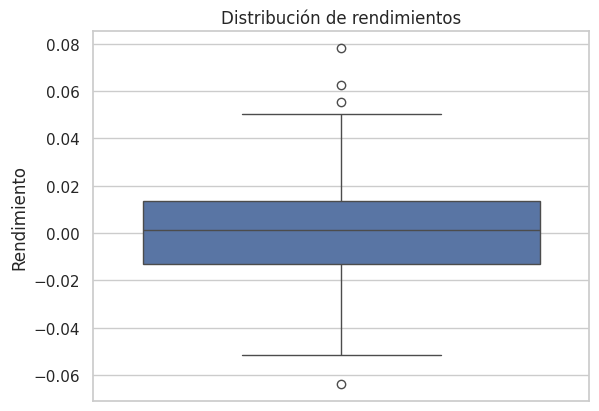

In [10]:
sns.boxplot(y=rendimientos_ejemplo)

plt.title("Distribución de rendimientos")
plt.ylabel("Rendimiento")

plt.show()



### Preguntas para interpretar

- ¿Dónde está la mediana?
- ¿Qué tan grande es la caja?
- ¿Qué tan largos son los bigotes?
- ¿Aparecen observaciones alejadas?

El objetivo no es memorizar la forma del dibujo.

El objetivo es poder decir:

> "La distribución presenta mayor/menor dispersión..."

y justificarlo a partir del gráfico.



# 9. Scatter plot: estudiar relaciones

Ahora queremos estudiar dos variables.

Por ejemplo:

> ¿Los cambios diarios de AAPL y MSFT tienden a ocurrir en la misma dirección?

Para eso usamos un **scatter plot**.

Cada punto representa una observación.


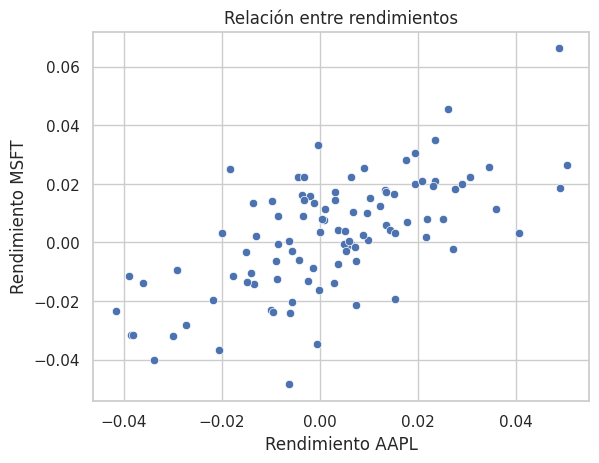

In [11]:
np.random.seed(10)

aapl = np.random.normal(0.001, 0.02, 100)
msft = aapl * 0.6 + np.random.normal(0, 0.015, 100)

sns.scatterplot(x=aapl, y=msft)

plt.title("Relación entre rendimientos")
plt.xlabel("Rendimiento AAPL")
plt.ylabel("Rendimiento MSFT")

plt.show()



## Interpretación

Buscamos patrones:

- nube ascendente → posible relación positiva;
- nube descendente → posible relación negativa;
- nube sin orientación clara → relación lineal débil o inexistente.

Pero recuerda:

> **Correlación no significa causalidad.**

Dos variables pueden moverse juntas sin que una sea la causa de la otra.



# 10. Correlación y mapa de calor

La correlación permite cuantificar la relación lineal entre dos variables.

En Python:

```python
df.corr()
```

produce una matriz de correlaciones.

Valores cercanos a:

- `1` → relación lineal positiva fuerte;
- `0` → relación lineal débil;
- `-1` → relación lineal negativa fuerte.

Veámoslo visualmente.


In [12]:
datos_rendimientos = pd.DataFrame({
    "AAPL": aapl,
    "MSFT": msft,
    "NVDA": aapl * 0.3 + np.random.normal(0, 0.025, 100)
})

correlacion = datos_rendimientos.corr()

correlacion


,AAPL,MSFT,NVDA
AAPL,1.000000,0.648544,0.207646
MSFT,0.648544,1.000000,0.205384
NVDA,0.207646,0.205384,1.000000


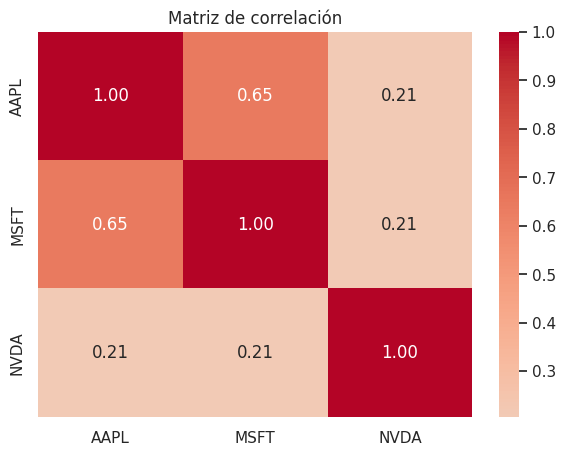

In [13]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlación")

plt.show()



## 🧠 Interpretar el heatmap

La matriz permite responder rápidamente:

> ¿Qué activos tienen comportamientos más similares?

Pero debemos tener cuidado:

- la correlación mide principalmente **relación lineal**;
- una correlación histórica no garantiza que se mantenga igual;
- correlación no significa causalidad;
- el período elegido afecta el resultado.

Para un análisis financiero serio también debemos considerar el período, frecuencia, calidad de datos y contexto del mercado.



# 11. Ahora sí: datos reales con yfinance 💰

Hasta este momento utilizamos datos pequeños o simulados para entender la visualización.

Ahora vamos a trabajar con datos reales.

Instalación, si el entorno todavía no tiene la librería:

```bash
pip install yfinance
```

Importamos:


In [14]:
import yfinance as yf



## ¿Qué activos vamos a estudiar?

Usaremos como ejemplo:

- `AAPL` — Apple
- `MSFT` — Microsoft
- `GOOGL` — Alphabet
- `AMZN` — Amazon
- `NVDA` — NVIDIA

Los símbolos son **tickers**, identificadores utilizados para localizar activos en los mercados.

> Los datos obtenidos mediante servicios externos pueden cambiar con el tiempo. Para una clase de EDA esto es útil: cada estudiante puede obtener una fotografía diferente del período consultado.


In [15]:
activos = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA"]

precios = yf.download(
    activos,
    start="2024-01-01",
    end="2026-01-01",
    auto_adjust=True
)

precios.head()


[*********************100%***********************]  5 of 5 completed


Price            Close                                                 \
Ticker            AAPL        AMZN       GOOGL        MSFT       NVDA   
Date                                                                    
2024-01-02  183.403992  149.929993  136.867615  363.117889  48.028793   
2024-01-03  182.030746  148.470001  137.610550  362.853607  47.431522   
2024-01-04  179.718948  144.570007  135.104385  360.249146  47.859287   
2024-01-05  178.997742  145.240005  134.450623  360.063141  48.955105   
2024-01-08  183.324997  149.100006  137.531296  366.858093  52.101982   

Price             High                                                 ...  \
Ticker            AAPL        AMZN       GOOGL        MSFT       NVDA  ...   
Date                                                                   ...   
2024-01-02  186.170269  152.380005  138.135548  368.042749  49.152535  ...   
2024-01-03  183.641118  151.050003  138.313864  365.458011  48.044743  ...   
2024-01-04  180.884728  147.380005  137.848280  365.301292  48.359835  ...   
2024-01-05  180.558713  146.589996  135.867151  364.283049  49.403805  ...   
2024-01-08  183.364524  149.399994  137.699692  367.357443  52.123922  ...   

Price             Open                                                 \
Ticker            AAPL        AMZN       GOOGL        MSFT       NVDA   
Date                                                                    
2024-01-02  184.895799  151.539993  137.244038  366.045381  49.101684   
2024-01-03  182.001109  149.199997  135.956293  361.296845  47.347766   
2024-01-04  179.956048  145.589996  137.115249  362.922093  47.628952   
2024-01-05  179.797998  144.690002  135.461012  361.257641  48.321942   
2024-01-08  179.896791  146.740005  135.005329  361.580743  49.368907   

Price         Volume                                           
Ticker          AAPL      AMZN     GOOGL      MSFT       NVDA  
Date                                                           
2024-01-02  82488700  47339400  23711200  25258600  411254000  
2024-01-03  58414500  49425500  24212100  23083500  320896000  
2024-01-04  71983600  56039800  27137700  20901500  306535000  
2024-01-05  62379700  45153100  22513900  21004600  415039000  
2024-01-08  59144500  46757100  21404000  23134000  642510000  

[5 rows x 25 columns]


# 12. Antes de graficar: conozcamos nuestros datos

Una regla fundamental de EDA:

> **No empieces a graficar sin conocer primero el DataFrame.**

Preguntas básicas:

- ¿cuántas filas tenemos?
- ¿cuántas columnas?
- ¿qué tipo de datos?
- ¿hay valores faltantes?
- ¿qué período cubren?


In [16]:
print("Dimensiones:", precios.shape)

precios.info()


Dimensiones: (502, 25)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 502 entries, 2024-01-02 to 2025-12-31
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (Close, AAPL)    502 non-null    float64
 1   (Close, AMZN)    502 non-null    float64
 2   (Close, GOOGL)   502 non-null    float64
 3   (Close, MSFT)    502 non-null    float64
 4   (Close, NVDA)    502 non-null    float64
 5   (High, AAPL)     502 non-null    float64
 6   (High, AMZN)     502 non-null    float64
 7   (High, GOOGL)    502 non-null    float64
 8   (High, MSFT)     502 non-null    float64
 9   (High, NVDA)     502 non-null    float64
 10  (Low, AAPL)      502 non-null    float64
 11  (Low, AMZN)      502 non-null    float64
 12  (Low, GOOGL)     502 non-null    float64
 13  (Low, MSFT)      502 non-null    float64
 14  (Low, NVDA)      502 non-null    float64
 15  (Open, AAPL)     502 non-null    float64
 16  (Open, AMZN)     502

In [17]:
precios.describe()


Price        Close                                                  \
Ticker        AAPL        AMZN       GOOGL        MSFT        NVDA   
count   502.000000  502.000000  502.000000  502.000000  502.000000   
mean    218.163908  201.084920  186.196406  436.391724  130.434591   
std      29.061802   23.894482   44.695116   44.590891   36.478682   
min     163.220627  144.570007  130.161407  350.446045   47.431522   
25%     197.301445  182.045002  160.382675  404.577202  107.877956   
50%     220.355453  199.269997  171.818108  420.492249  129.622086   
75%     234.987228  223.067505  193.867229  475.532753  157.790558   
max     285.413116  254.000000  322.601013  537.646423  206.545166   

Price         High                                                  ...  \
Ticker        AAPL        AMZN       GOOGL        MSFT        NVDA  ...   
count   502.000000  502.000000  502.000000  502.000000  502.000000  ...   
mean    220.247258  203.257610  188.240375  439.904431  132.605680  ...   
std      29.157374   24.065589   45.248698   44.664832   36.763190  ...   
min     164.605523  146.589996  131.984083  360.251011   48.044743  ...   
25%     199.331448  184.752499  162.219134  407.837397  110.606060  ...   
50%     222.591318  200.525002  173.761189  423.625063  132.120719  ...   
75%     237.294625  225.872498  195.231437  480.116581  158.770643  ...   
max     287.836529  258.600006  327.977016  550.013114  211.682867  ...   

Price         Open                                                  \
Ticker        AAPL        AMZN       GOOGL        MSFT        NVDA   
count   502.000000  502.000000  502.000000  502.000000  502.000000   
mean    217.941190  201.160956  186.098553  436.394022  130.481371   
std      29.027178   24.115082   44.736023   44.931147   36.636462   
min     163.566886  144.690002  130.636902  346.808801   47.347766   
25%     196.633060  182.320004  160.184686  404.190597  107.114857   
50%     219.779620  199.305000  172.185861  420.292283  129.651063   
75%     234.190534  223.520004  192.999155  476.422511  157.940185   
max     285.423116  255.360001  325.363817  549.795235  207.582673   

Price         Volume                                                          
Ticker          AAPL          AMZN         GOOGL          MSFT          NVDA  
count   5.020000e+02  5.020000e+02  5.020000e+02  5.020000e+02  5.020000e+02  
mean    5.564712e+07  4.270025e+07  3.183945e+07  2.138683e+07  2.992817e+08  
std     2.732569e+07  1.823593e+07  1.448971e+07  8.027734e+06  1.537611e+08  
min     1.791060e+07  1.142050e+07  1.009740e+07  5.855900e+06  6.552850e+07  
25%     4.132715e+07  3.153310e+07  2.236578e+07  1.632950e+07  1.841153e+08  
50%     4.890840e+07  3.871275e+07  2.853320e+07  1.958820e+07  2.505988e+08  
75%     6.041002e+07  4.680382e+07  3.582398e+07  2.359505e+07  3.779842e+08  
max     3.186799e+08  1.663408e+08  1.274901e+08  7.083610e+07  1.142269e+09  

[8 rows x 25 columns]

In [18]:
precios.isna().sum()


Price   Ticker
Close   AAPL      0
        AMZN      0
        GOOGL     0
        MSFT      0
        NVDA      0
High    AAPL      0
        AMZN      0
        GOOGL     0
        MSFT      0
        NVDA      0
Low     AAPL      0
        AMZN      0
        GOOGL     0
        MSFT      0
        NVDA      0
Open    AAPL      0
        AMZN      0
        GOOGL     0
        MSFT      0
        NVDA      0
Volume  AAPL      0
        AMZN      0
        GOOGL     0
        MSFT      0
        NVDA      0
dtype: int64


### 🧪 Mini-reto

Antes de continuar, responde:

1. ¿Cuántas observaciones tenemos?
2. ¿Cuál es la primera fecha?
3. ¿Cuál es la última fecha?
4. ¿Existen valores faltantes?
5. ¿Qué representa cada nivel de columnas?

**No continúes hasta intentar responderlas.**



# 13. Seleccionar el precio de cierre

`yfinance` devuelve varias variables para cada activo, entre ellas:

- Open
- High
- Low
- Close
- Volume

Para nuestro primer análisis utilizaremos **Close**, el precio de cierre ajustado según la configuración utilizada.



In [19]:
cierre = precios["Close"]

cierre.head()


Ticker,AAPL,AMZN,GOOGL,MSFT,NVDA
Date,,,,,
2024-01-02,183.403992,149.929993,136.867615,363.117889,48.028793
2024-01-03,182.030746,148.470001,137.610550,362.853607,47.431522
2024-01-04,179.718948,144.570007,135.104385,360.249146,47.859287
2024-01-05,178.997742,145.240005,134.450623,360.063141,48.955105
2024-01-08,183.324997,149.100006,137.531296,366.858093,52.101982



## Visualicemos los precios

Primera pregunta del EDA:

> **¿Cómo evolucionaron los precios de los activos durante el período?**


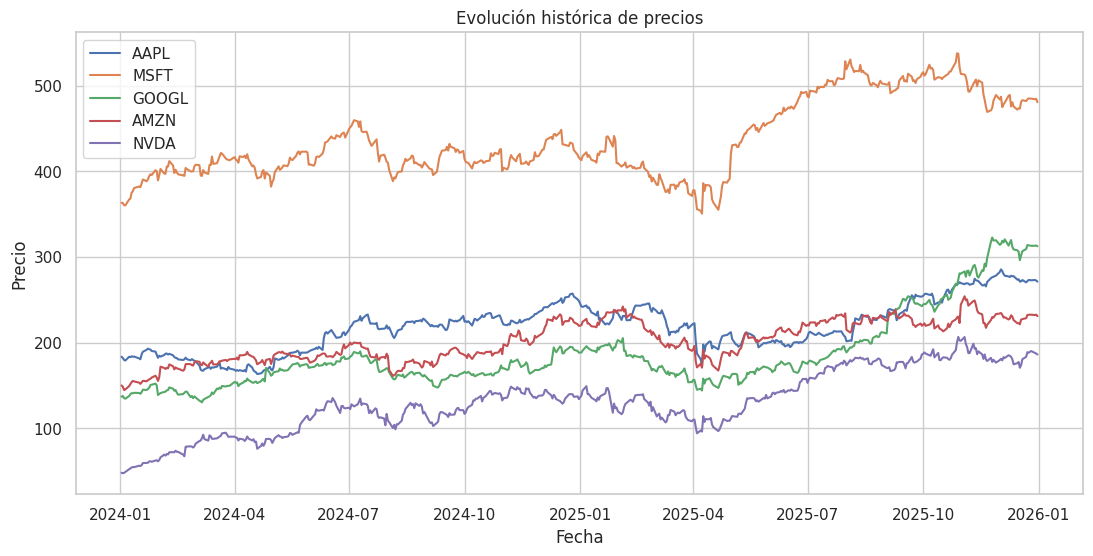

In [20]:
fig, ax = plt.subplots(figsize=(13, 6))

for activo in activos:
    ax.plot(cierre.index, cierre[activo], label=activo)

ax.set_title("Evolución histórica de precios")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio")
ax.legend()

plt.show()



## ⚠️ Una dificultad de comparar precios

AAPL puede tener un precio nominal diferente de NVDA, MSFT, etc.

Eso hace que comparar las alturas directamente pueda ser engañoso.

Una solución sencilla para estudiar **crecimiento relativo** es normalizar las series.

Por ejemplo:

```python
precio_normalizado = precio / precio_inicial * 100
```

Así todos comienzan en 100.


In [21]:
cierre_normalizado = cierre / cierre.iloc[0] * 100

cierre_normalizado.head()


Ticker,AAPL,AMZN,GOOGL,MSFT,NVDA
Date,,,,,
2024-01-02,100.000000,100.000000,100.000000,100.000000,100.000000
2024-01-03,99.251246,99.026218,100.542813,99.927219,98.756431
2024-01-04,97.990751,96.425008,98.711726,99.209969,99.647074
2024-01-05,97.597517,96.871882,98.234066,99.158745,101.928659
2024-01-08,99.956929,99.446417,100.484907,101.030025,108.480723


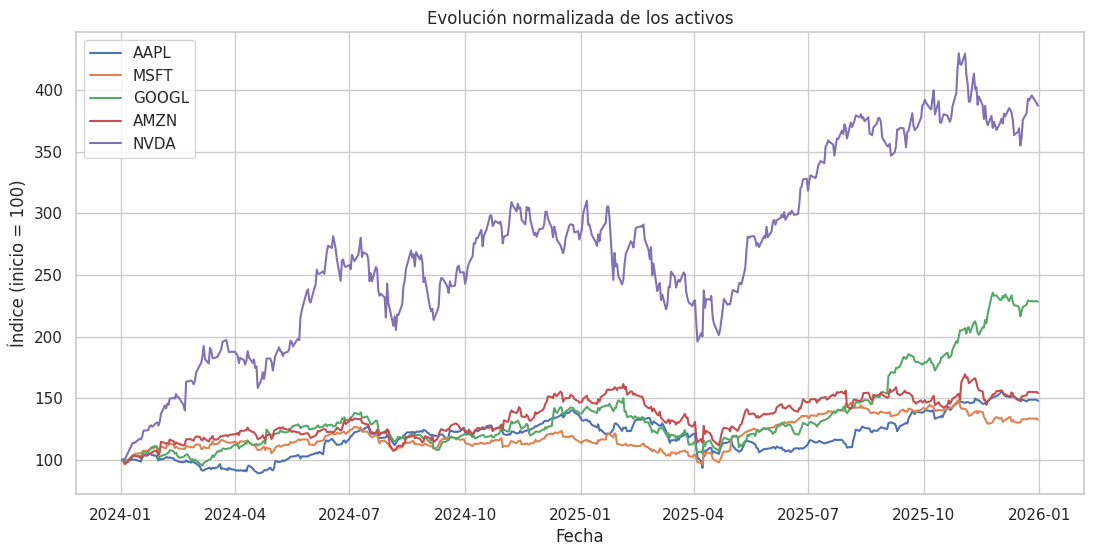

In [22]:
fig, ax = plt.subplots(figsize=(13, 6))

for activo in activos:
    ax.plot(
        cierre_normalizado.index,
        cierre_normalizado[activo],
        label=activo
    )

ax.set_title("Evolución normalizada de los activos")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice (inicio = 100)")
ax.legend()

plt.show()



### ¿Qué pregunta responde este gráfico?

No responde:

> "¿Cuál tiene el precio más alto?"

Responde mejor:

> **"¿Cómo cambió cada activo respecto a su propio punto inicial?"**

Esta distinción es fundamental en análisis de datos financieros.



# 14. Rendimientos: transformar los precios

En análisis financiero suele ser útil estudiar **rendimientos** en lugar de precios.

Un rendimiento porcentual simple entre dos períodos puede calcularse como:

\[
R_t = \frac{P_t-P_{t-1}}{P_{t-1}}
\]

En Pandas podemos obtenerlo con:

```python
pct_change()
```


In [23]:
rendimientos = cierre.pct_change()

rendimientos.head()


Ticker,AAPL,AMZN,GOOGL,MSFT,NVDA
Date,,,,,
2024-01-02,NaN,NaN,NaN,NaN,NaN
2024-01-03,-0.007488,-0.009738,0.005428,-0.000728,-0.012436
2024-01-04,-0.012700,-0.026268,-0.018212,-0.007178,0.009019
2024-01-05,-0.004013,0.004634,-0.004839,-0.000516,0.022897
2024-01-08,0.024175,0.026577,0.022913,0.018872,0.064281



El primer registro normalmente será `NaN` porque no tenemos un precio anterior con el cual compararlo.

Eliminemos esos valores para las visualizaciones que lo necesiten.


In [24]:
rendimientos = rendimientos.dropna()

rendimientos.head()


Ticker,AAPL,AMZN,GOOGL,MSFT,NVDA
Date,,,,,
2024-01-03,-0.007488,-0.009738,0.005428,-0.000728,-0.012436
2024-01-04,-0.012700,-0.026268,-0.018212,-0.007178,0.009019
2024-01-05,-0.004013,0.004634,-0.004839,-0.000516,0.022897
2024-01-08,0.024175,0.026577,0.022913,0.018872,0.064281
2024-01-09,-0.002264,0.015225,0.015197,0.002936,0.016975



# 15. EDA de los rendimientos

### Pregunta 1
**¿Cómo se comportan los rendimientos a través del tiempo?**


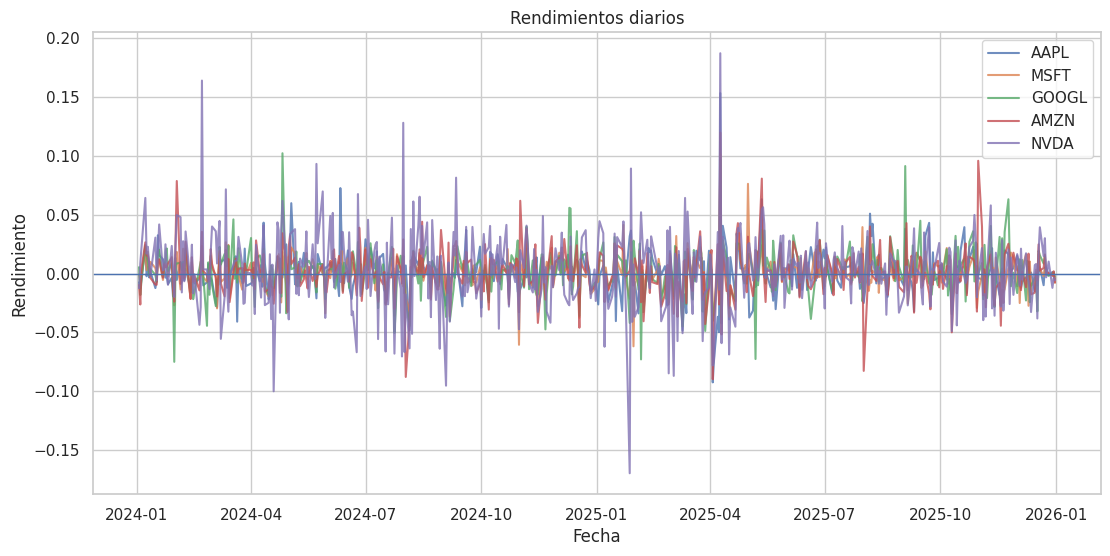

In [25]:
fig, ax = plt.subplots(figsize=(13, 6))

for activo in activos:
    ax.plot(
        rendimientos.index,
        rendimientos[activo],
        label=activo,
        alpha=0.8
    )

ax.axhline(0, linewidth=1)
ax.set_title("Rendimientos diarios")
ax.set_xlabel("Fecha")
ax.set_ylabel("Rendimiento")
ax.legend()

plt.show()



### Interpretación

La línea horizontal en cero nos ayuda a distinguir:

- valores positivos → rendimiento positivo;
- valores negativos → rendimiento negativo.

Busca:

- períodos de mayor variabilidad;
- movimientos extremos;
- momentos donde varios activos caen simultáneamente;
- diferencias entre activos.

**No confundas variabilidad con rendimiento.**

Un activo puede tener grandes movimientos hacia arriba y hacia abajo y terminar cerca del punto inicial.



# 16. Distribución de rendimientos

Ahora usamos Seaborn para estudiar una variable desde otro ángulo.

Pregunta:

> **¿Cómo se distribuyen los rendimientos diarios de cada activo?**


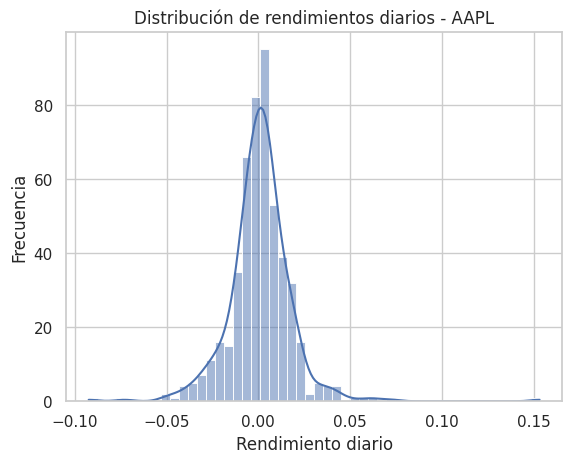

In [26]:
sns.histplot(
    data=rendimientos,
    x="AAPL",
    bins=50,
    kde=True
)

plt.title("Distribución de rendimientos diarios - AAPL")
plt.xlabel("Rendimiento diario")
plt.ylabel("Frecuencia")

plt.show()



## 🧪 Cambia el activo

Modifica `"AAPL"` por:

```python
"MSFT"
"GOOGL"
"AMZN"
"NVDA"
```

### Pregunta

¿Qué diferencias observas entre las distribuciones?

No busques solamente cuál "se ve mejor".

Describe:

- centro;
- dispersión;
- valores extremos;
- forma de la distribución.



# 17. Comparar la dispersión con un boxplot

Ahora podemos comparar todos los activos simultáneamente.


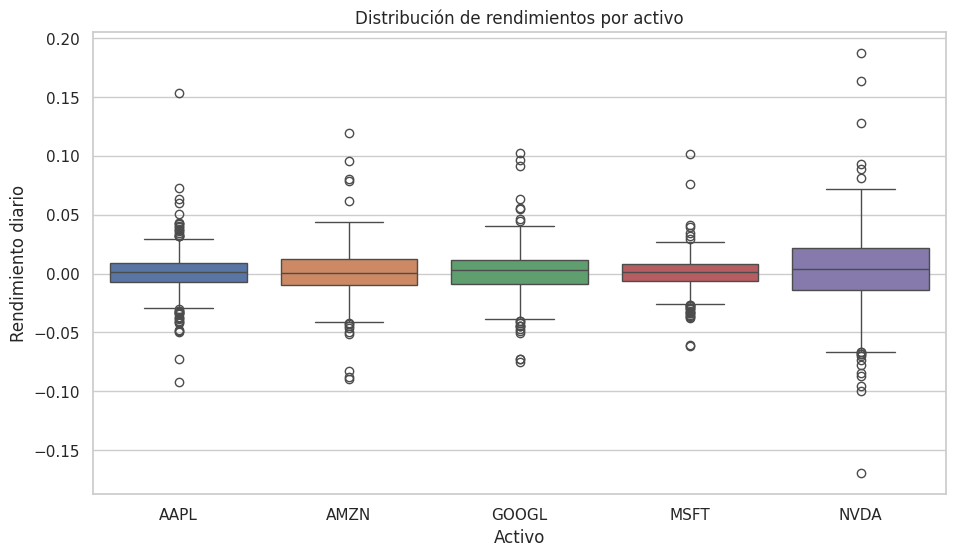

In [27]:
plt.figure(figsize=(11, 6))

sns.boxplot(data=rendimientos)

plt.title("Distribución de rendimientos por activo")
plt.xlabel("Activo")
plt.ylabel("Rendimiento diario")

plt.show()



### Preguntas de análisis

1. ¿Qué activos muestran mayor dispersión?
2. ¿Qué activos presentan más observaciones alejadas?
3. ¿Las medianas están cerca de cero?
4. ¿Qué información perderíamos si solo observáramos el precio?

Aquí aparece una idea importante:

> **Una buena visualización permite comparar una propiedad concreta de los datos.**



# 18. Matriz de correlación del portafolio

Ahora llegamos a una de las visualizaciones más importantes para nuestro caso.

Pregunta:

> **¿Cómo se relacionan los rendimientos de los activos entre sí?**


In [28]:
correlacion = rendimientos.corr()

correlacion


Ticker,AAPL,AMZN,GOOGL,MSFT,NVDA
Ticker,,,,,
AAPL,1.000000,0.484033,0.442987,0.479062,0.350518
AMZN,0.484033,1.000000,0.540440,0.625640,0.505377
GOOGL,0.442987,0.540440,1.000000,0.485902,0.398910
MSFT,0.479062,0.625640,0.485902,1.000000,0.549245
NVDA,0.350518,0.505377,0.398910,0.549245,1.000000


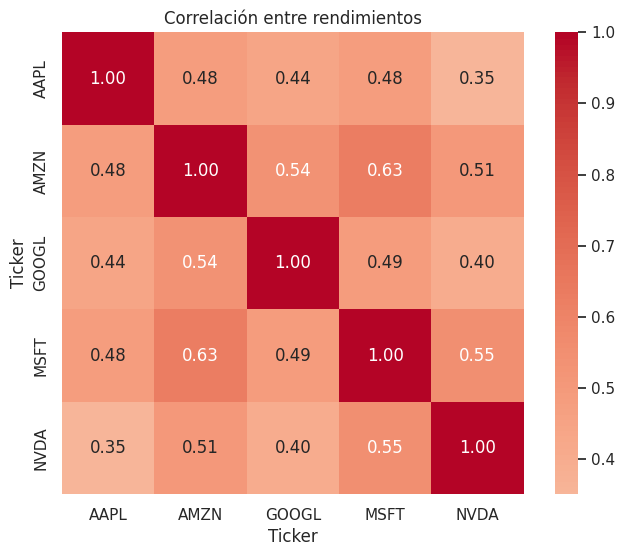

In [29]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlación entre rendimientos")

plt.show()



## 🧠 ¿Cómo leer la matriz?

Supongamos que encontramos:

```text
             AAPL    MSFT
AAPL          1.00   0.70
MSFT          0.70   1.00
```

La diagonal es 1 porque cada activo está perfectamente correlacionado consigo mismo.

Un valor de `0.70` indica una relación lineal positiva relativamente alta en el período analizado.

### Pregunta de portafolio

Si dos activos presentan una correlación elevada:

> ¿Qué implica esto para la diversificación?

Una posible interpretación es que **pueden proporcionar menos diversificación entre sí que dos activos con una correlación menor**, aunque la diversificación real depende de muchos otros factores.

No debemos convertir la correlación, por sí sola, en una recomendación de inversión.



# 19. Scatter plot: profundicemos en una pareja

Seleccionemos dos activos:

```python
AAPL
MSFT
```

Cada punto representa un día.

- X → rendimiento de AAPL
- Y → rendimiento de MSFT



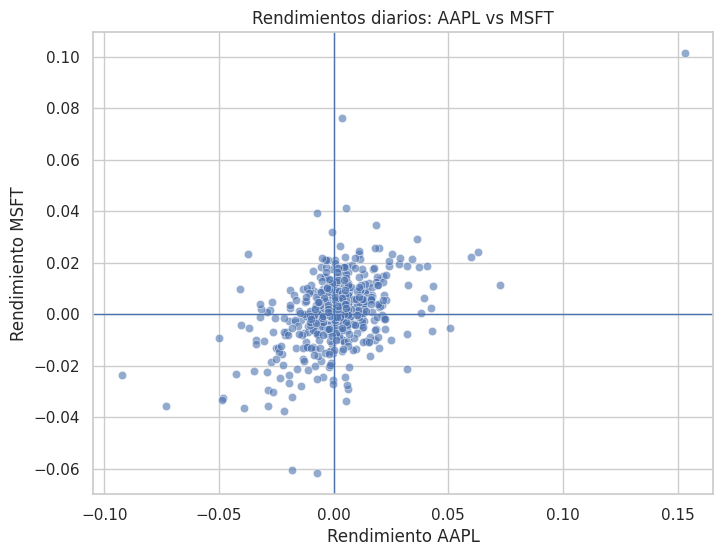

In [30]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=rendimientos,
    x="AAPL",
    y="MSFT",
    alpha=0.6
)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.title("Rendimientos diarios: AAPL vs MSFT")
plt.xlabel("Rendimiento AAPL")
plt.ylabel("Rendimiento MSFT")

plt.show()



### Preguntas para interpretar

Observa la nube de puntos:

1. ¿Existe una orientación ascendente?
2. ¿Qué ocurre cuando AAPL tiene rendimiento negativo?
3. ¿MSFT suele tener el mismo signo?
4. ¿Hay valores extremos?
5. ¿La relación parece perfectamente lineal?

El scatter plot y la matriz de correlación están contando historias relacionadas, pero desde perspectivas diferentes:

**Scatter → vemos las observaciones individuales.**  
**Correlación → resumimos numéricamente la relación lineal.**



# 20. Estadísticas descriptivas del portafolio

La visualización debe complementarse con medidas numéricas.



In [31]:
resumen = pd.DataFrame({
    "Media": rendimientos.mean(),
    "Mediana": rendimientos.median(),
    "Desviación estándar": rendimientos.std(),
    "Mínimo": rendimientos.min(),
    "Máximo": rendimientos.max()
})

resumen


,Media,Mediana,Desviación estándar,Mínimo,Máximo
Ticker,,,,,
AAPL,0.000933,0.001187,0.017571,-0.092456,0.153289
AMZN,0.001056,0.000648,0.019781,-0.089791,0.119770
GOOGL,0.001829,0.002923,0.019062,-0.075003,0.102243
MSFT,0.000657,0.001111,0.013975,-0.061809,0.101337
NVDA,0.003222,0.003503,0.032181,-0.169682,0.187227



## ¿Qué estamos viendo?

### Media
Promedio de los rendimientos.

### Mediana
Valor central de la distribución.

### Desviación estándar
Medida de dispersión utilizada frecuentemente como una aproximación de la volatilidad histórica.

### Mínimo / máximo
Permiten observar los extremos registrados en el período.

**Importante:** estas estadísticas describen el período analizado. No garantizan que el futuro se comporte igual.



# 21. Mini-proyecto: EDA completo

Ahora debes construir tu propio análisis.

## Objetivo

Selecciona entre **3 y 5 activos** y realiza un EDA.

### Paso 1 — Datos

Descarga los datos históricos.

### Paso 2 — Calidad

Revisa:

- dimensiones;
- tipos;
- valores faltantes;
- período.

### Paso 3 — Precios

Construye un gráfico de evolución de precios.

### Paso 4 — Normalización

Construye un gráfico con todas las series comenzando en 100.

### Paso 5 — Rendimientos

Calcula los rendimientos diarios.

### Paso 6 — Distribución

Construye un histograma para uno de los activos.

### Paso 7 — Comparación

Construye un boxplot de los rendimientos.

### Paso 8 — Relación

Construye una matriz de correlación.

### Paso 9 — Relación entre dos activos

Construye un scatter plot.

### Paso 10 — Conclusiones

Escribe **3 hallazgos**.

Cada hallazgo debe tener esta estructura:

> **Gráfico:** ¿qué gráfico utilizaste?  
> **Observación:** ¿qué ves?  
> **Interpretación:** ¿qué significa esa observación para el análisis?



# 22. Reto final 🎯

Sin modificar el código inicialmente:

### Pregunta 1
¿Cuál activo presenta mayor dispersión de rendimientos?

### Pregunta 2
¿Cuáles dos activos presentan mayor correlación?

### Pregunta 3
¿Cuáles presentan menor correlación?

### Pregunta 4
¿Existe algún día donde varios activos tengan movimientos extremos simultáneamente?

### Pregunta 5
¿La evolución normalizada cuenta la misma historia que los precios originales?

### Pregunta 6
¿Qué información aporta el histograma que no aporta el gráfico temporal?

### Pregunta 7
¿Qué información aporta el scatter plot que no aporta el heatmap?

---

## ⭐ Regla de oro del EDA

Antes de hacer un gráfico pregunta:

> **¿Qué quiero saber?**

Después del gráfico pregunta:

> **¿Qué estoy observando?**

Y finalmente:

> **¿Qué puedo concluir razonablemente a partir de lo observado?**



# 📚 Referencias

- [Matplotlib — documentación oficial](https://matplotlib.org/stable/)
- [Matplotlib — galería de ejemplos](https://matplotlib.org/stable/gallery/)
- [Matplotlib — introducción a Figure y Axes](https://matplotlib.org/stable/users/explain/figure/figure_intro.html)
- [Seaborn — documentación oficial](https://seaborn.pydata.org/)
- [Pandas — visualización](https://pandas.pydata.org/docs/user_guide/visualization.html)
- [yfinance — documentación](https://ranaroussi.github.io/yfinance/)

### Nota sobre los datos

Los datos obtenidos mediante `yfinance` corresponden a información histórica de mercado y pueden cambiar dependiendo del período consultado, ajustes y disponibilidad. Este notebook tiene finalidad educativa y de análisis de datos; no constituye asesoría financiera.
